<a href="https://colab.research.google.com/github/Musarrat1/Assembly/blob/main/tealeaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("✅ Memory growth set")

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Memory growth set


In [2]:
import os, glob, numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive

 classification_report.txt
 Classroom
'Colab Notebooks'
'Cv (2) (1).pdf'
'Cv (2).pdf'
 CV.pdf
 gradcam_outputs
 IMG_3124.JPG
 IMG_3180.JPG
 IMG_3349.JPG
 IMG_3389.JPG
 IMG_3399.JPG
 IMG_3401.JPG
 IMG_3404.JPG
 IMG_3409.JPG
 IMG_3410.JPG
 IMG_3411.JPG
 IMG_3418.JPG
 IMG_3447.JPG
 IMG_3459.JPG
 IMG_3468.JPG
 IMG_3479.JPG
 IMG_3827.JPG
 IMG_3828.JPG
 IMG_3831.JPG
 IMG_3832.JPG
 IMG_3864.JPG
 IMG_3865.JPG
 IMG_4508.JPG
 IMG_4773.JPG
 IMG_4973.JPG
 IMG_5072.JPG
 IMG_5078.JPG
 IMG_5081.JPG
 IMG_5090.JPG
 IMG_5140.JPG
 IMG_5141.JPG
 IMG_5148.JPG
 IMG_5190.JPG
 IMG_5197.JPG
 IMG_5201.JPG
 IMG_5203.JPG
 IMG_5265.JPG
 IMG_5266.JPG
 IMG_5267.JPG
 IMG_5268.JPG
 IMG_5273.JPG
 IMG_5577.JPG
 IMG_5631.JPG
 IMG_5666.JPG
 IMG_5669.JPG
 IMG_5735.JPG
 IMG_5791.JPG
 IMG_5824.JPG
 IMG_5826.JPG
 IMG_5853.JPG
 IMG_5855.JPG
 IMG_5866.JPG
 IMG_6043.JPG
 IMG_6174.JPG
 IMG_6194.JPG
 IMG_6238.JPG
 IMG_6353.JPG
 IMG_6356.JPG
 IMG_6474.JPG
 IMG_6476.JPG
 IMG_6590.JPG
 IMG_6593.JPG
 IMG_7010.JPG
 IMG_7344.JPG
 IMG_73

In [5]:
!cp /content/drive/MyDrive/TeaDataset.zip /content/
!mkdir -p /content/dataset
!unzip -o /content/TeaDataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5917.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5918.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5919.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust592.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5920.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5921.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5922.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5923.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5924.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5925.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5926.jpg  
  inflating: /c

In [6]:
import os, glob
import pandas as pd

DATA_DIR = "/content/dataset/TeaDataset/TeaDataset"

filepaths, labels = [], []

for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        for img_path in glob.glob(os.path.join(class_path, "*.*")):
            if img_path.lower().endswith((".jpg",".jpeg",".png",".webp",".bmp")):
                filepaths.append(img_path)
                labels.append(class_name)

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print(df["label"].value_counts())
print("Total:", len(df))

label
Brown Blight       14507
Helopelties        14289
Red rust           14001
7. Healthy leaf    13764
Grey Blight         2024
Name: count, dtype: int64
Total: 58585


In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=123
)

print("Train:\n", train_df["label"].value_counts())
print("\nVal:\n", val_df["label"].value_counts())

Train:
 label
Brown Blight       11606
Helopelties        11431
Red rust           11201
7. Healthy leaf    11011
Grey Blight         1619
Name: count, dtype: int64

Val:
 label
Brown Blight       2901
Helopelties        2858
Red rust           2800
7. Healthy leaf    2753
Grey Blight         405
Name: count, dtype: int64


In [8]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
BATCH = 8   # safest (if stable you can use 16)

class_names = sorted(df["label"].unique())
num_classes = len(class_names)
print("Classes:", class_names)

label_table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int64)
    ),
    default_value=-1
)

def decode_and_resize(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img

def process_image(path, label_str):
    img = decode_and_resize(path)
    label_id = label_table.lookup(label_str)
    label_oh = tf.one_hot(label_id, num_classes)
    return img, label_oh

def df_to_dataset(dataframe, shuffle=True):
    paths = dataframe["filepath"].values
    labs  = dataframe["label"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labs))
    if shuffle:
        ds = ds.shuffle(len(dataframe), seed=123, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, l: process_image(p, tf.cast(l, tf.string)),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = df_to_dataset(train_df, shuffle=True)
val_ds   = df_to_dataset(val_df, shuffle=False)

print("✅ Dataset ready")

Classes: ['7. Healthy leaf', 'Brown Blight', 'Grey Blight', 'Helopelties', 'Red rust']
✅ Dataset ready


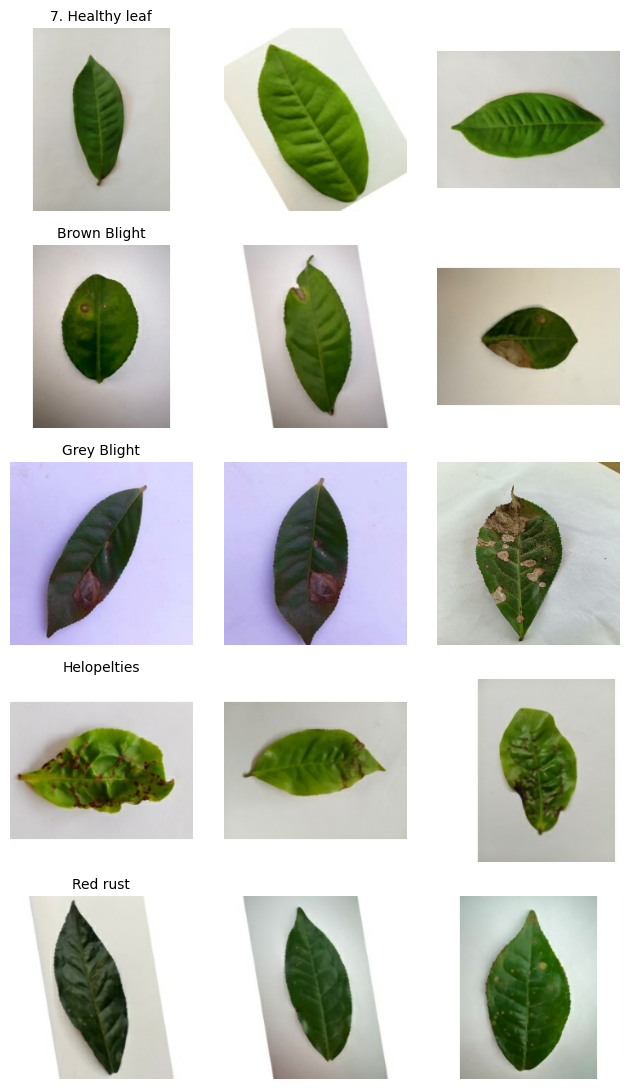

In [9]:
import matplotlib.pyplot as plt

N_PER_CLASS = 3
samples = {i: [] for i in range(num_classes)}

for images, labels_batch in train_ds:
    y = np.argmax(labels_batch.numpy(), axis=1)
    for i, cls in enumerate(y):
        if len(samples[cls]) < N_PER_CLASS:
            samples[cls].append(images[i].numpy().astype("uint8"))
    if all(len(samples[k]) >= N_PER_CLASS for k in samples):
        break

plt.figure(figsize=(N_PER_CLASS*2.2, num_classes*2.2))
idx = 1
for r in range(num_classes):
    for c in range(N_PER_CLASS):
        plt.subplot(num_classes, N_PER_CLASS, idx)
        plt.imshow(samples[r][c])
        plt.axis("off")
        if c == 0:
            plt.title(class_names[r], fontsize=10)
        idx += 1
plt.tight_layout()
plt.show()

In [10]:
import glob, os

counts = {}
for c in class_names:
    counts[c] = len(glob.glob(os.path.join(DATA_DIR, c, "*.*")))
total = sum(counts.values())
K = len(class_names)

class_weights = {i: total/(K*counts[class_names[i]]) for i in range(K)}
class_weights_clipped = {k: float(min(v, 1.8)) for k, v in class_weights.items()}

print("Weights:", class_weights_clipped)

USE_CLASS_WEIGHT = True  # set False if unstable

Weights: {0: 0.8512786980528916, 1: 0.807679051492383, 2: 1.8, 3: 0.8200013996780741, 4: 0.8368687950860653}


In [11]:
from tensorflow.keras import layers

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=(class_weights_clipped if USE_CLASS_WEIGHT else None),
    callbacks=callbacks
)

Epoch 1/5
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 244s 39ms/step - accuracy: 0.9041 - loss: 0.2674 - val_accuracy: 0.9514 - val_loss: 0.1442 - learning_rate: 0.0010
Epoch 2/5
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 220s 38ms/step - accuracy: 0.9553 - loss: 0.1174 - val_accuracy: 0.9676 - val_loss: 0.1015 - learning_rate: 0.0010
Epoch 3/5
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 220s 38ms/step - accuracy: 0.9575 - loss: 0.1120 - val_accuracy: 0.9602 - val_loss: 0.1195 - learning_rate: 0.0010
Epoch 4/5
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 220s 38ms/step - accuracy: 0.9581 - loss: 0.1103 - val_accuracy: 0.9579 - val_loss: 0.1316 - learning_rate: 0.0010
Epoch 5/5
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 220s 38ms/step - accuracy: 0.9624 - loss: 0.1014 - val_accuracy: 0.9733 - val_loss: 0.0898 - learning_rate: 5.0000e-04


In [13]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=(class_weights_clipped if USE_CLASS_WEIGHT else None),
    callbacks=callbacks
)

Epoch 1/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 290s 47ms/step - accuracy: 0.8891 - loss: 0.2948 - val_accuracy: 0.9723 - val_loss: 0.0840 - learning_rate: 1.0000e-05
Epoch 2/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 272s 46ms/step - accuracy: 0.9474 - loss: 0.1372 - val_accuracy: 0.9758 - val_loss: 0.0698 - learning_rate: 1.0000e-05
Epoch 3/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 273s 47ms/step - accuracy: 0.9640 - loss: 0.0978 - val_accuracy: 0.9787 - val_loss: 0.0614 - learning_rate: 1.0000e-05
Epoch 4/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 325s 47ms/step - accuracy: 0.9701 - loss: 0.0773 - val_accuracy: 0.9788 - val_loss: 0.0621 - learning_rate: 1.0000e-05
Epoch 5/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 274s 47ms/step - accuracy: 0.9736 - loss: 0.0644 - val_accuracy: 0.9819 - val_loss: 0.0505 - learning_rate: 1.0000e-05
Epoch 6/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 319s 46ms/step - accuracy: 0.9775 - loss: 0.0578 - val_accuracy: 0.9839 - val_loss: 0.0478 - learning_rate: 1.0000e-05
Epoch 7/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━

True dist: {'Brown Blight': 2901, '7. Healthy leaf': 2753, 'Red rust': 2800, 'Helopelties': 2858, 'Grey Blight': 405}
Pred dist: {'Brown Blight': 2879, '7. Healthy leaf': 2775, 'Red rust': 2799, 'Helopelties': 2815, 'Grey Blight': 449}
                 precision    recall  f1-score   support

7. Healthy leaf     0.9885    0.9964    0.9924      2753
   Brown Blight     0.9868    0.9793    0.9830      2901
    Grey Blight     0.8552    0.9481    0.8993       405
    Helopelties     0.9993    0.9843    0.9917      2858
       Red rust     0.9889    0.9886    0.9887      2800

       accuracy                         0.9857     11717
      macro avg     0.9637    0.9793    0.9710     11717
   weighted avg     0.9862    0.9857    0.9858     11717



<Figure size 800x800 with 0 Axes>

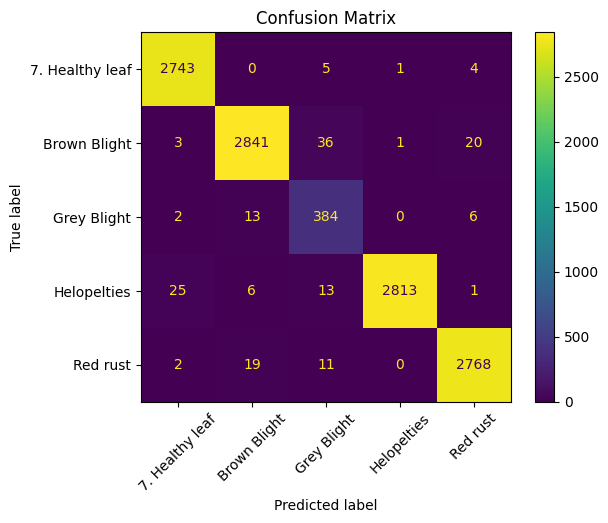

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import matplotlib.pyplot as plt

y_true, y_pred = [], []

for x, y in val_ds:
    p = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(p, axis=1))

print("True dist:", {class_names[k]: v for k, v in Counter(y_true).items()})
print("Pred dist:", {class_names[k]: v for k, v in Counter(y_pred).items()})

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
plt.figure(figsize=(8,8))
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

✅ True distribution: {'Brown Blight': 2901, '7. Healthy leaf': 2753, 'Red rust': 2800, 'Helopelties': 2858, 'Grey Blight': 405}
✅ Pred distribution: {'Brown Blight': 2879, '7. Healthy leaf': 2775, 'Red rust': 2799, 'Helopelties': 2815, 'Grey Blight': 449}

✅ Classification Report:

                 precision    recall  f1-score   support

7. Healthy leaf     0.9885    0.9964    0.9924      2753
   Brown Blight     0.9868    0.9793    0.9830      2901
    Grey Blight     0.8552    0.9481    0.8993       405
    Helopelties     0.9993    0.9843    0.9917      2858
       Red rust     0.9889    0.9886    0.9887      2800

       accuracy                         0.9857     11717
      macro avg     0.9637    0.9793    0.9710     11717
   weighted avg     0.9862    0.9857    0.9858     11717



<Figure size 800x800 with 0 Axes>

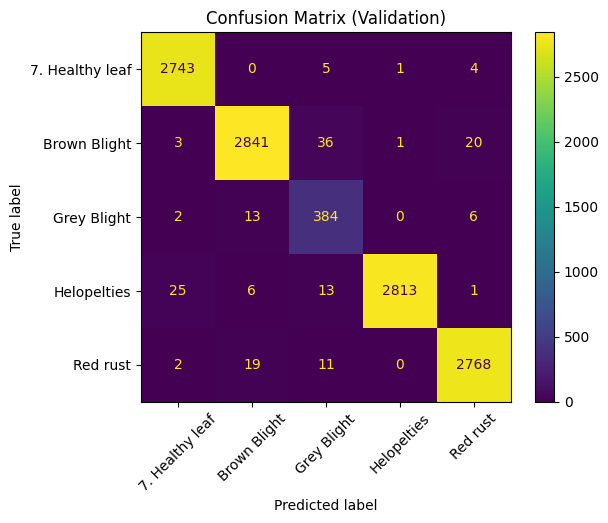

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

y_true, y_pred = [], []

for x, y in val_ds:
    p = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(p, axis=1))

print("✅ True distribution:", {class_names[k]: v for k, v in Counter(y_true).items()})
print("✅ Pred distribution:", {class_names[k]: v for k, v in Counter(y_pred).items()})

print("\n✅ Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

plt.figure(figsize=(8,8))
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Validation)")
plt.show()

In [16]:
remedy = {
    "7. Healthy leaf": "Healthy: maintain field hygiene and regular monitoring.",
    "Brown Blight": "Remove infected leaves, improve airflow, avoid overhead watering; fungicide if severe.",
    "Grey Blight": "Prune infected parts, reduce humidity, ensure spacing; fungicide if needed.",
    "Red Rust": "Reduce shading, increase sunlight; copper spray if necessary.",
    "Helopelties": "Helopeltis (tea mosquito bug): IPM—monitoring, pruning; neem/approved control if needed."
}

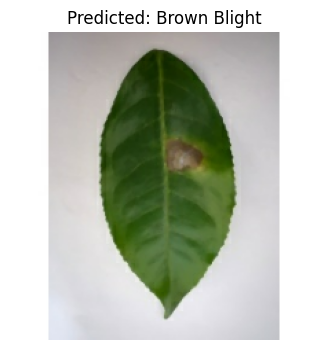

Predicted: Brown Blight
Remedy: Remove infected leaves, improve airflow, avoid overhead watering; fungicide if severe.


In [17]:
import matplotlib.pyplot as plt
import numpy as np

images, _ = next(iter(val_ds))
img = images[0]

pred = model.predict(tf.expand_dims(img, axis=0), verbose=0)
pred_class = class_names[int(np.argmax(pred[0]))]

plt.figure(figsize=(4,4))
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")
plt.title(f"Predicted: {pred_class}")
plt.show()

print("Predicted:", pred_class)
print("Remedy:", remedy.get(pred_class, "Consult an agriculture expert."))

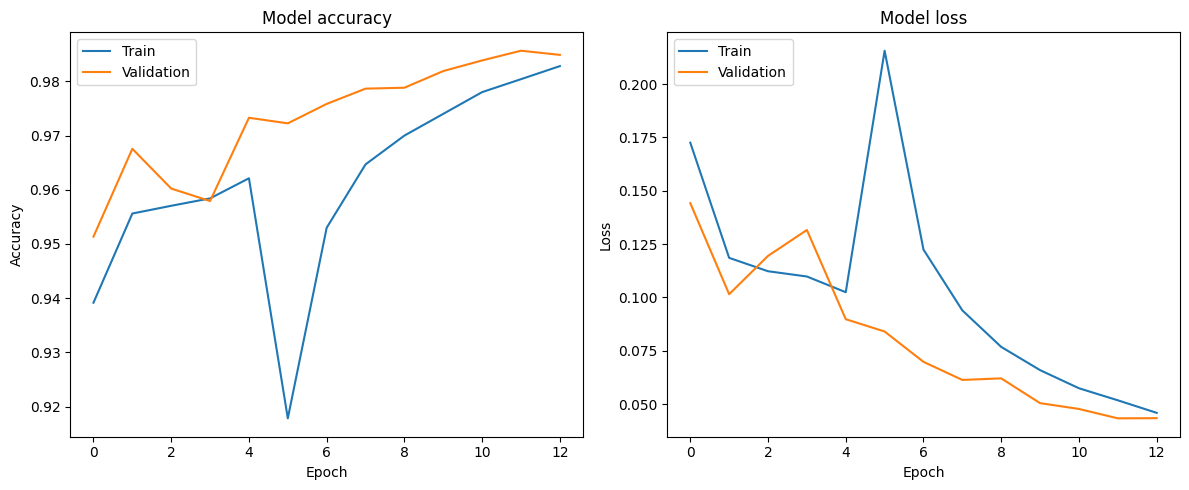

In [18]:
import matplotlib.pyplot as plt

# Combine history for initial training and fine-tuning
combined_history = {
    'accuracy': history.history['accuracy'] + history_ft.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'] + history_ft.history['val_accuracy'],
    'loss': history.history['loss'] + history_ft.history['loss'],
    'val_loss': history.history['val_loss'] + history_ft.history['val_loss']
}

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(combined_history['accuracy'])
plt.plot(combined_history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(combined_history['loss'])
plt.plot(combined_history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [19]:
model.save("tea_leaf_model_final.keras")
!cp tea_leaf_model_final.keras /content/drive/MyDrive/
print("✅ Saved to Drive: tea_leaf_model_final.keras")

✅ Saved to Drive: tea_leaf_model_final.keras


The plots above show the accuracy and loss curves during the training process, including both the initial training and the fine-tuning steps. You can observe how the model performed on both the training and validation datasets over the epochs.